In [10]:
import sys
sys.path.append("../")

import tqdm
import pandas
import joblib
import sklearn.compose
import sklearn.preprocessing
import sklearn.model_selection
import matplotlib.pyplot as plt

from lazyfca import LazyFCA

from utils import estimate_quality

In [11]:
data = pandas.read_csv("../datasets/churn.csv")
data = data.drop(columns = ['customerID'])
data = data[data["TotalCharges"] != ' ']
data["TotalCharges"] = data["TotalCharges"].astype(float)

cols_to_replace = ['MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
data[cols_to_replace] = data[cols_to_replace].replace(['No phone service', 'No internet service'], 'No')

X = data.drop(columns = ["Churn"])
# y = data["Churn"].to_numpy()
y = (data["Churn"] == "Yes").to_numpy()
X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size = 0.1, stratify = y, random_state = 42
)

numeric = [ "tenure", "MonthlyCharges", "TotalCharges" ]
categorical = list(set(X_train.columns) - set(numeric))
ct = sklearn.compose.ColumnTransformer(
    transformers = [
        ("numeric", 'passthrough', numeric),
        ("categorical", sklearn.preprocessing.OneHotEncoder(dtype = 'bool'), categorical)
    ]
)
X_train = pandas.DataFrame(ct.fit_transform(X_train), columns = ct.get_feature_names_out())
X_test = pandas.DataFrame(ct.transform(X_test), columns = ct.get_feature_names_out())

categorical = [ feature for feature in ct.get_feature_names_out() if feature.startswith("categorical__") ]
X_train[categorical] = X_train[categorical].astype(bool)
X_test[categorical] = X_test[categorical].astype(bool)

y_train = pandas.Series(y_train)
y_test = pandas.Series(y_test)

### V0 (do not touch)

In [12]:
classifier = LazyFCA(
    pos_params=LazyFCA.Params(
        supporters_covered=5,
        supporter_opposer_ratio=1 / 2.75,
    ),
    neg_params=LazyFCA.Params(
        supporters_covered=10,
        supporter_opposer_ratio=4,
    ),
    pos_weight=1.0
)
classifier.fit(X_train, y_train)

In [13]:
y_pred = classifier.predict(X_test)
estimate_quality(y_pred, y_test)

100%|██████████| 704/704 [01:42<00:00,  6.89it/s]


{'Accuracy': 0.7571022727272727,
 'Precision': 0.5289855072463768,
 'Recall': 0.7807486631016043,
 'AUC-ROC': 0.8241448504845933,
 'F1-score': 0.6306695464362851,
 'True Positive': 146,
 'True Negative': 387,
 'False Positive': 130,
 'False Negative': 41,
 'True Negative Rate (Specificity)': 0.7485493230174082,
 'Negative Predictive Value': 0.9042056074766355,
 'False Positive Rate': 0.2514506769825919,
 'False Discovery Rate': 0.47101449275362317}

In [5]:
score = classifier.explain_sample(X_test.iloc[502]).display()
score

,Hypothesis,Type,Supporters,Opposers,Supporters covered,Opposers covered,Supporters to opposers ratio,Support,Error rate,Precision,...,Description volume,Simplicity prior,Query binary similarity,Query numeric similarity,Query similarity,Query weighted precision,Query weighted WRAcc,Stability,Robustness,Delta stability
0,0; 0; 0; 0; 0; 0; 0; 0; 1; 0; 0; 1; 0; 0; 0; 0...,POSITIVE,1682,4646,5,6,0.833333,0.002973,0.001291,0.454545,...,0.044470,0.576273,0.4375,0.459156,0.448328,0.203786,0.000147,0.046672,0.046672,1.0
1,0; 0; 0; 0; 0; 0; 0; 0; 1; 0; 0; 1; 0; 0; 0; 0...,POSITIVE,1682,4646,7,14,0.500000,0.004162,0.003013,0.333333,...,0.063165,0.591716,0.3750,0.476666,0.425833,0.141944,0.000095,0.066105,0.066105,1.0
2,0; 0; 0; 0; 0; 0; 0; 0; 1; 0; 0; 1; 0; 0; 0; 0...,POSITIVE,1682,4646,341,874,0.390160,0.202735,0.188119,0.280658,...,0.111630,0.576010,0.1875,0.347251,0.267376,0.075041,0.000763,0.109375,0.109375,1.0
3,0; 0; 0; 0; 0; 0; 0; 0; 1; 0; 0; 1; 0; 0; 0; 0...,POSITIVE,1682,4646,6,12,0.500000,0.003567,0.002583,0.333333,...,0.057264,0.585956,0.4375,0.487831,0.462666,0.154222,0.000089,0.032790,0.032790,1.0
4,0; 0; 0; 0; 0; 0; 0; 0; 1; 0; 0; 1; 0; 0; 0; 0...,POSITIVE,1682,4646,5,13,0.384615,0.002973,0.002798,0.277778,...,0.060008,0.580743,0.4375,0.472512,0.455006,0.126391,0.000015,0.033337,0.033337,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3550,0; 0; 0; 1; 0; 0; 0; 0; 1; 0; 0; 1; 0; 0; 0; 0...,NEGATIVE,4646,1682,244,26,9.384615,0.052518,0.015458,0.903704,...,0.089374,0.540391,0.6250,0.427266,0.526133,0.475468,0.003805,0.070175,0.070175,1.0
3551,0; 0; 0; 1; 0; 0; 0; 0; 1; 0; 0; 1; 0; 0; 0; 0...,NEGATIVE,4646,1682,25,0,inf,0.005381,0.000000,1.000000,...,0.004146,0.624693,0.5625,0.649214,0.605857,0.605857,0.000636,0.008649,0.008649,1.0
3552,0; 0; 0; 0; 0; 0; 0; 1; 0; 0; 0; 1; 0; 0; 0; 0...,NEGATIVE,4646,1682,32,0,inf,0.006888,0.000000,1.000000,...,0.081933,0.604954,0.3750,0.513648,0.444324,0.444324,0.000597,0.093611,0.093611,1.0
3553,0; 0; 0; 0; 0; 0; 0; 0; 1; 0; 0; 1; 0; 0; 0; 0...,NEGATIVE,4646,1682,74,1,74.000000,0.015928,0.000595,0.986667,...,0.037392,0.579393,0.5625,0.524057,0.543278,0.536035,0.001626,0.011535,0.011535,1.0


In [6]:
all_explanations = classifier.explain(X_test)
len(all_explanations)

100%|██████████| 704/704 [01:59<00:00,  5.89it/s]


704

In [7]:
scores = pandas.concat(map(lambda explanation: explanation.display(), all_explanations), axis = 0).drop_duplicates()
scores

,Hypothesis,Type,Supporters,Opposers,Supporters covered,Opposers covered,Supporters to opposers ratio,Support,Error rate,Precision,...,Description volume,Simplicity prior,Query binary similarity,Query numeric similarity,Query similarity,Query weighted precision,Query weighted WRAcc,Stability,Robustness,Delta stability
0,0; 0; 0; 0; 1; 1; 0; 0; 1; 0; 0; 1; 0; 0; 0; 0...,POSITIVE,1682,4646,139,132,1.053030,0.082640,0.028412,0.512915,...,0.096159,0.571575,0.6250,0.528227,0.576613,0.295754,0.006102,0.124878,0.124878,1.0
1,0; 0; 0; 0; 1; 0; 0; 0; 1; 0; 0; 1; 0; 0; 0; 0...,POSITIVE,1682,4646,55,49,1.122449,0.032699,0.010547,0.528846,...,0.107245,0.565579,0.6250,0.509677,0.567339,0.300035,0.002453,0.060067,0.060067,1.0
2,0; 0; 0; 0; 1; 1; 0; 0; 1; 0; 0; 1; 0; 0; 0; 0...,POSITIVE,1682,4646,171,103,1.660194,0.101665,0.022170,0.624088,...,0.013280,0.630165,0.5625,0.663113,0.612807,0.382445,0.009507,0.187500,0.187500,1.0
3,0; 0; 0; 0; 1; 1; 0; 0; 0; 0; 0; 1; 0; 0; 0; 0...,POSITIVE,1682,4646,41,41,1.000000,0.024376,0.008825,0.500000,...,0.118362,0.536941,0.8125,0.498707,0.655604,0.327802,0.001990,0.123047,0.123047,1.0
4,0; 0; 0; 0; 1; 1; 0; 0; 1; 0; 0; 1; 0; 0; 0; 0...,POSITIVE,1682,4646,73,76,0.960526,0.043401,0.016358,0.489933,...,0.193714,0.519326,0.7500,0.407762,0.578881,0.283613,0.003055,0.184570,0.184570,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1670,0; 0; 0; 0; 0; 0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0...,NEGATIVE,4646,1682,15,0,inf,0.003229,0.000000,1.000000,...,0.073099,0.620457,0.3750,0.554951,0.464976,0.464976,0.000293,0.101052,0.101052,1.0
1671,0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 1; 0; 0; 0; 0...,NEGATIVE,4646,1682,18,4,4.500000,0.003874,0.002378,0.818182,...,0.039006,0.631679,0.5000,0.639139,0.569570,0.466012,0.000166,0.123072,0.123072,1.0
1672,0; 1; 0; 0; 0; 0; 0; 0; 0; 1; 0; 1; 0; 0; 0; 0...,NEGATIVE,4646,1682,20,0,inf,0.004305,0.000000,1.000000,...,0.020205,0.597274,0.6250,0.603504,0.614252,0.614252,0.000516,0.246465,0.246465,1.0
1673,0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 1; 0; 0; 0; 0...,NEGATIVE,4646,1682,38,9,4.222222,0.008179,0.005351,0.808511,...,0.012011,0.643949,0.3125,0.585971,0.449235,0.363212,0.000248,0.373413,0.373413,1.0


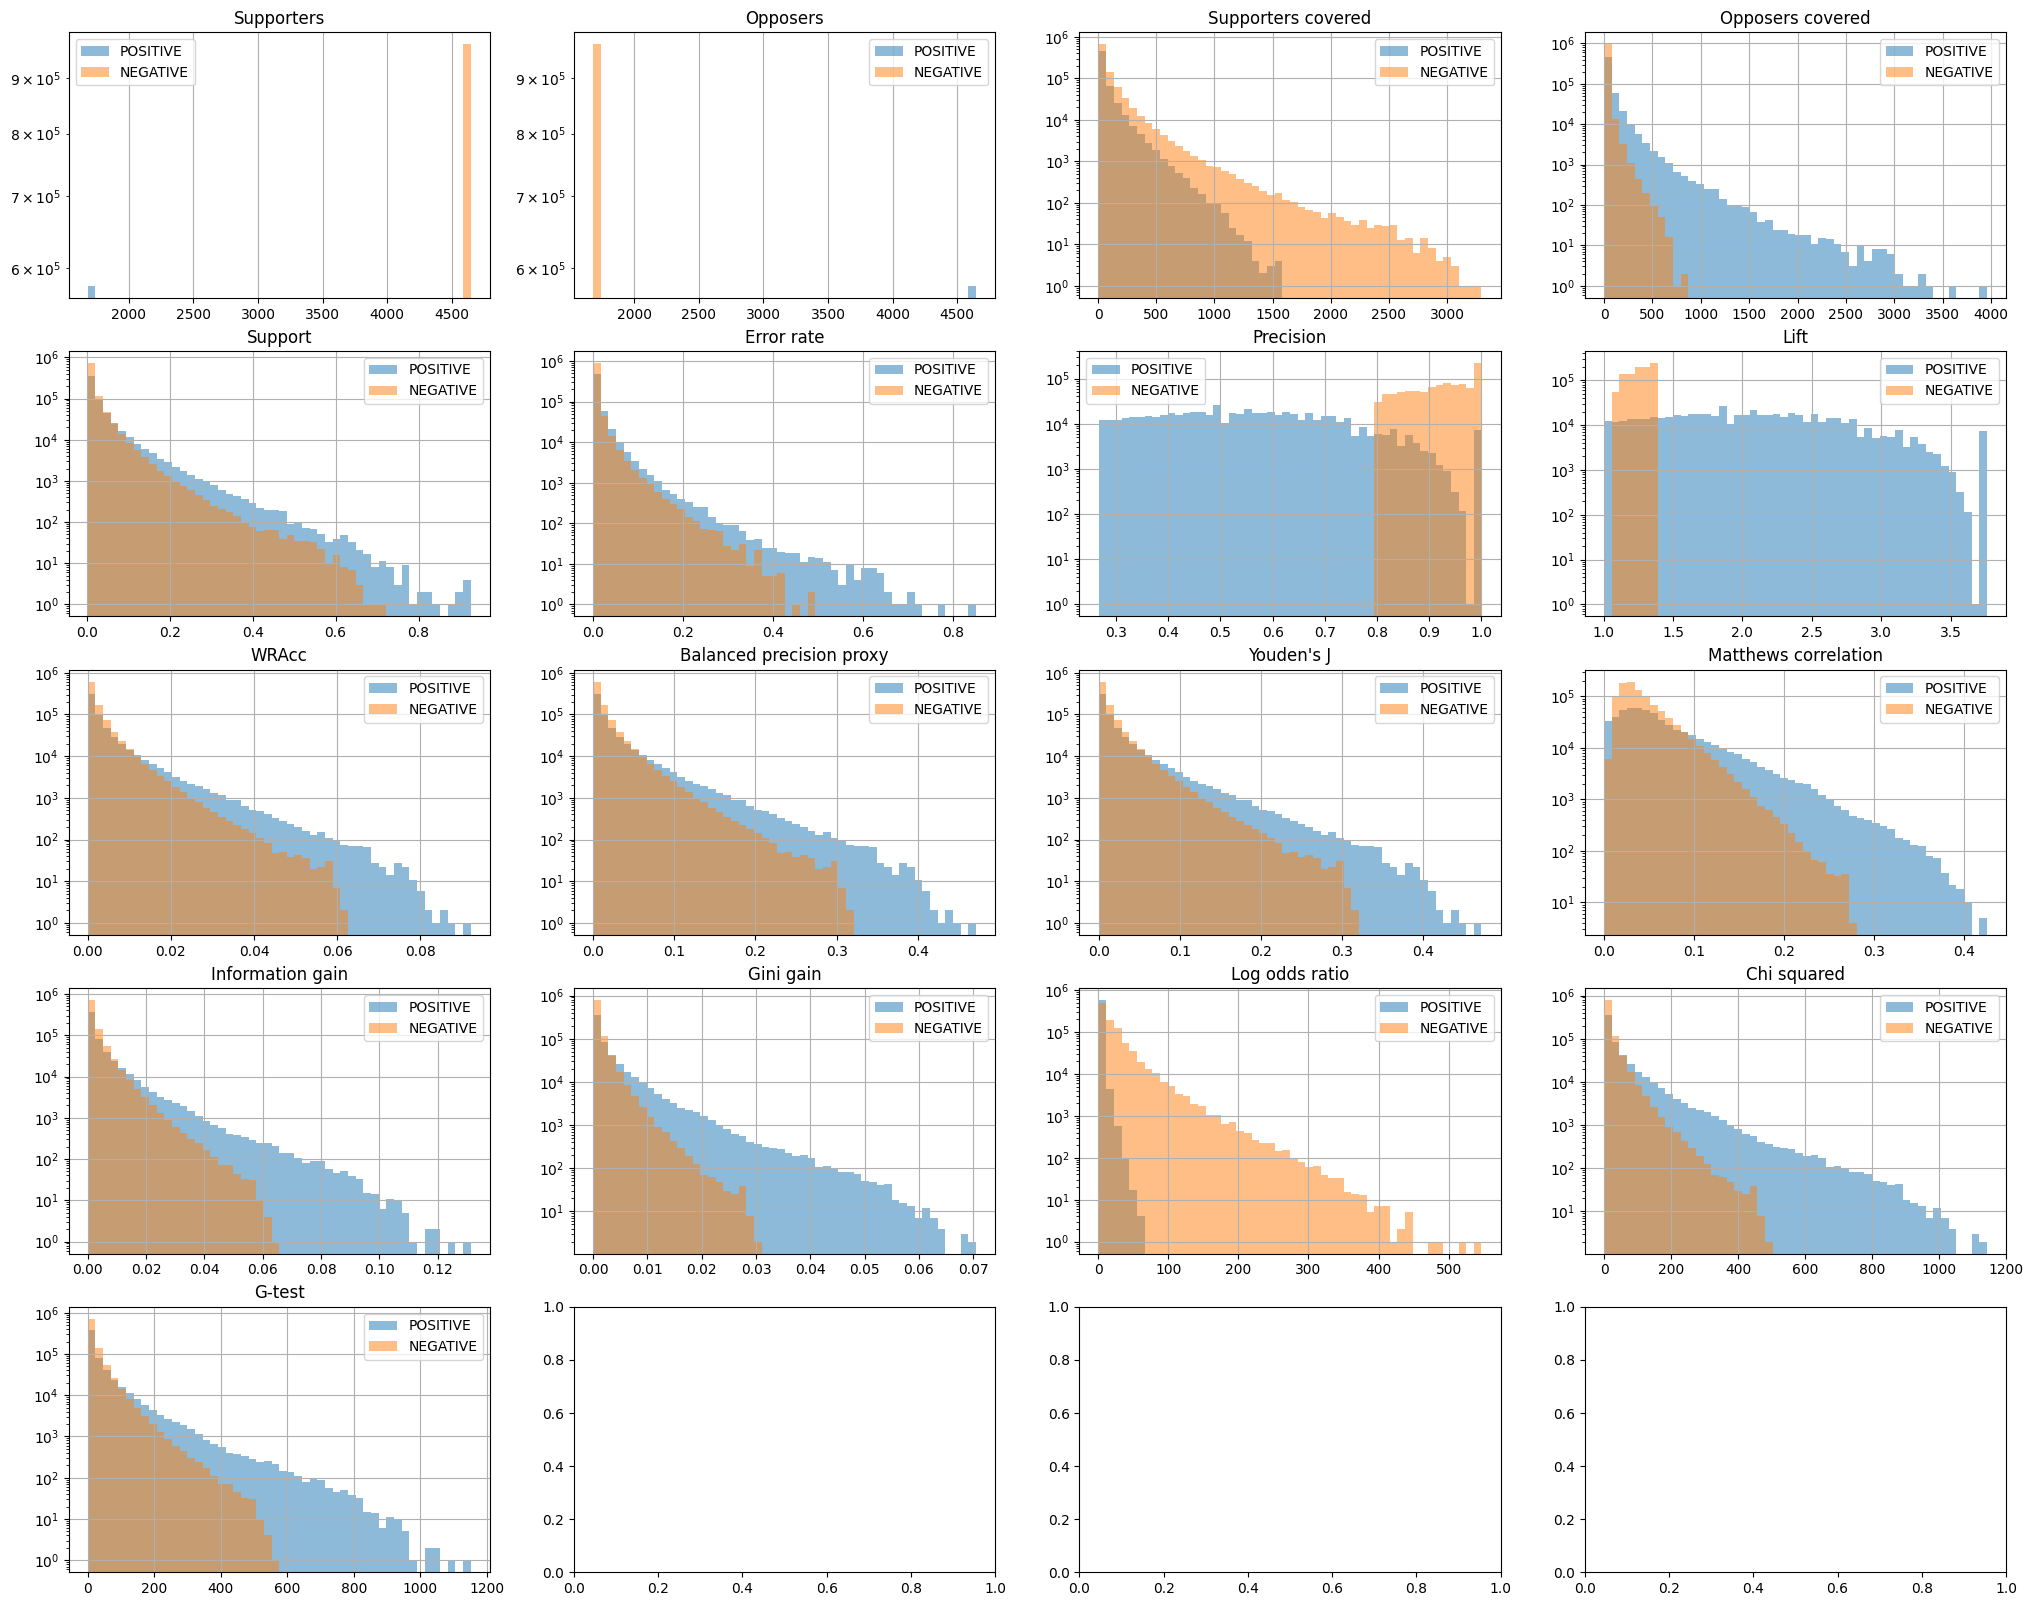

In [8]:
COLUMNS = [
    'Supporters', 'Opposers', 'Supporters covered', 'Opposers covered',
    'Support', 'Error rate', 'Precision', 'Lift', 'WRAcc',
    'Balanced precision proxy', 'Youden\'s J', 'Matthews correlation',
    "Information gain", "Gini gain", "Log odds ratio", "Chi squared", "G-test"
]
fig, axes = plt.subplots(5, 4, figsize = (25, 20))
for column, ax in zip(COLUMNS, axes.flat):
    ax.set_title(column)
    range = (scores[column].min(), scores[column].max())
    scores[scores["Type"] == "POSITIVE"][column].hist(ax = ax, bins = 50, alpha = 0.5, range = range, label = 'POSITIVE')
    scores[scores["Type"] == "NEGATIVE"][column].hist(ax = ax, bins = 50, alpha = 0.5, range = range, label = 'NEGATIVE')
    ax.legend()
    ax.set_yscale('log')

### V1

In [9]:
scores

,Hypothesis,Type,Supporters,Opposers,Supporters covered,Opposers covered,Supporters to opposers ratio,Support,Error rate,Precision,...,Description volume,Simplicity prior,Query binary similarity,Query numeric similarity,Query similarity,Query weighted precision,Query weighted WRAcc,Stability,Robustness,Delta stability
0,0; 0; 0; 0; 1; 1; 0; 0; 1; 0; 0; 1; 0; 0; 0; 0...,POSITIVE,1682,4646,139,132,1.053030,0.082640,0.028412,0.512915,...,0.096159,0.571575,0.6250,0.528227,0.576613,0.295754,0.006102,0.124878,0.124878,1.0
1,0; 0; 0; 0; 1; 0; 0; 0; 1; 0; 0; 1; 0; 0; 0; 0...,POSITIVE,1682,4646,55,49,1.122449,0.032699,0.010547,0.528846,...,0.107245,0.565579,0.6250,0.509677,0.567339,0.300035,0.002453,0.060067,0.060067,1.0
2,0; 0; 0; 0; 1; 1; 0; 0; 1; 0; 0; 1; 0; 0; 0; 0...,POSITIVE,1682,4646,171,103,1.660194,0.101665,0.022170,0.624088,...,0.013280,0.630165,0.5625,0.663113,0.612807,0.382445,0.009507,0.187500,0.187500,1.0
3,0; 0; 0; 0; 1; 1; 0; 0; 0; 0; 0; 1; 0; 0; 0; 0...,POSITIVE,1682,4646,41,41,1.000000,0.024376,0.008825,0.500000,...,0.118362,0.536941,0.8125,0.498707,0.655604,0.327802,0.001990,0.123047,0.123047,1.0
4,0; 0; 0; 0; 1; 1; 0; 0; 1; 0; 0; 1; 0; 0; 0; 0...,POSITIVE,1682,4646,73,76,0.960526,0.043401,0.016358,0.489933,...,0.193714,0.519326,0.7500,0.407762,0.578881,0.283613,0.003055,0.184570,0.184570,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1670,0; 0; 0; 0; 0; 0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0...,NEGATIVE,4646,1682,15,0,inf,0.003229,0.000000,1.000000,...,0.073099,0.620457,0.3750,0.554951,0.464976,0.464976,0.000293,0.101052,0.101052,1.0
1671,0; 0; 0; 0; 1; 0; 0; 0; 0; 0; 0; 1; 0; 0; 0; 0...,NEGATIVE,4646,1682,18,4,4.500000,0.003874,0.002378,0.818182,...,0.039006,0.631679,0.5000,0.639139,0.569570,0.466012,0.000166,0.123072,0.123072,1.0
1672,0; 1; 0; 0; 0; 0; 0; 0; 0; 1; 0; 1; 0; 0; 0; 0...,NEGATIVE,4646,1682,20,0,inf,0.004305,0.000000,1.000000,...,0.020205,0.597274,0.6250,0.603504,0.614252,0.614252,0.000516,0.246465,0.246465,1.0
1673,0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 0; 1; 0; 0; 0; 0...,NEGATIVE,4646,1682,38,9,4.222222,0.008179,0.005351,0.808511,...,0.012011,0.643949,0.3125,0.585971,0.449235,0.363212,0.000248,0.373413,0.373413,1.0


In [48]:
import numpy
import itertools
import os

from lazyfca.explanation import Explanation

METRICS = [
    'Supporters covered', 'Opposers covered', 'Support', 'Error rate',
    'Precision', 'Lift', 'WRAcc', 'Balanced precision proxy', 'Youden\'s J',
    'Matthews correlation', "Information gain", "Gini gain",
    "Log odds ratio", "Chi squared", "G-test"
]

pos_clas_coef_values = [ 0.5, 1.0, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0 ]

for metric in METRICS:
    if os.path.exists(f"filtration/{metric}.csv"):
        print(f"Skipping '{metric}', already exists")
        continue
    print(f"Processing '{metric}'")

    positive = scores[scores["Type"] == "POSITIVE"][metric]
    positive = numpy.linspace(positive.min(), positive.max(), 10)
    
    negative = scores[scores["Type"] == "NEGATIVE"][metric]
    negative = numpy.linspace(negative.min(), negative.max(), 10)

    attempts = list(itertools.product(positive, negative))
    results = []
    for pos_value, neg_value in tqdm.tqdm(attempts):
        classif = LazyFCA(
            pos_params=LazyFCA.Params.from_dict({metric: pos_value}),
            neg_params=LazyFCA.Params.from_dict({metric: neg_value}),
            pos_weight=1.0
        )
        num_clas = classif.classify_explanations(all_explanations, trust=False, probs=False)
        for coef in pos_clas_coef_values:
            y_pred = num_clas.copy()
            y_pred[:, 1] = y_pred[:, 1] * coef
            total = y_pred.sum(axis = 1, keepdims = True)
            y_pred = numpy.divide(y_pred, numpy.maximum(1e-18, total))
            results.append({
                "metric": metric,
                "pos_value": pos_value,
                "neg_value": neg_value,
                "pos_weight": coef,
                "avg_positive": num_clas[:, 1].mean(),
                "avg_negative": num_clas[:, 0].mean(),
                **estimate_quality(y_pred, y_test),
            })
    pandas.DataFrame(results).to_csv(f"filtration/{metric}.csv")

Processing 'Supporters covered'


100%|██████████| 100/100 [01:02<00:00,  1.60it/s]


Processing 'Opposers covered'


100%|██████████| 100/100 [02:08<00:00,  1.29s/it]


Processing 'Support'


...

100%|██████████| 100/100 [02:07<00:00,  1.28s/it]


Processing 'Chi squared'


100%|██████████| 100/100 [02:33<00:00,  1.53s/it]


Processing 'G-test'


100%|██████████| 100/100 [02:30<00:00,  1.50s/it]


In [51]:
all = pandas.concat([
    pandas.read_csv(f"filtration/{metric}.csv")
    for metric in METRICS
])
all.to_csv("filtration/all.csv", index=False)